In [ ]:
!pip install --upgrade --force-reinstall numpy==2.1.3 scikit-learn==1.5.2 joblib==1.4.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 10.0 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.2
    Uninstalling joblib-1.5.2:
      Successfully uninstalled joblib-1.5.2
  Attempting uninstall: scipy
    Found ex

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import itertools
import joblib
from datetime import datetime

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)

from tensorflow.keras import layers, models, regularizers, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

print("TF version:", tf.__version__)
print("GPU:", "available" if tf.config.list_physical_devices('GPU') else "NOT available")

TF version: 2.19.0
GPU: NOT available


In [ ]:
# drive mount
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# === Cell 1: Mount Drive & Dataset Path ===
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Machine_Learning/Research_base_Model/chest_xray_dataset'
assert os.path.exists(BASE_PATH), f"Dataset path not found: {BASE_PATH}"
print("Dataset path:", BASE_PATH)

train_dir = os.path.join(BASE_PATH, 'train')
val_dir   = os.path.join(BASE_PATH, 'val')
test_dir  = os.path.join(BASE_PATH, 'test')

for d in [train_dir, val_dir, test_dir]:
    if not os.path.exists(d):
        raise FileNotFoundError(f"Missing folder: {d}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path: /content/drive/MyDrive/Machine_Learning/Research_base_Model/chest_xray_dataset


In [ ]:
# === Cell 2: Data generators / augmentation ===
IMG_SIZE = (224,224)
BATCH_SIZE = 32
COLOR_MODE = 'rgb'   # paper used grayscale, but keeping rgb is fine. Can change to 'grayscale' if desired.

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

eval_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir,
                                              target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE,
                                              class_mode='binary',
                                              shuffle=True,
                                              color_mode=COLOR_MODE,
                                              seed=SEED)

val_gen = eval_datagen.flow_from_directory(val_dir,
                                           target_size=IMG_SIZE,
                                           batch_size=BATCH_SIZE,
                                           class_mode='binary',
                                           shuffle=False,
                                           color_mode=COLOR_MODE,
                                           seed=SEED)

test_gen = eval_datagen.flow_from_directory(test_dir,
                                            target_size=IMG_SIZE,
                                            batch_size=BATCH_SIZE,
                                            class_mode='binary',
                                            shuffle=False,
                                            color_mode=COLOR_MODE,
                                            seed=SEED)

print("Classes:", train_gen.class_indices)
print("Train samples:", train_gen.n, "Val:", val_gen.n, "Test:", test_gen.n)


Found 5207 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Train samples: 5207 Val: 16 Test: 624


In [ ]:
# === Cell 3: Build the custom CNN (22-layer style from paper) ===
def build_custom_cnn(input_shape=(224,224,3), l1_reg=0.001, dropout_rate=0.5):
    inputs = layers.Input(shape=input_shape)
    # Conv block 1
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Conv block 2
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Conv block 3
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Conv block 4
    x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Conv block 5
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Conv block 6
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Flatten()(x)

    # Dense feature layer (this is the feature vector we'll extract)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l1(l1_reg), name='feature_dense')(x)
    x = layers.Dropout(dropout_rate)(x)

    # Final classifier (sigmoid for binary)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='Custom22_CNN')
    return model

model = build_custom_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), l1_reg=0.001, dropout_rate=0.5)
model.summary()
print("Total params:", model.count_params())

Model: "Custom22_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_dense (Dense)           │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             

 Total params: 796,929 (3.04 MB)

 Trainable params: 795,585 (3.03 MB)

 Non-trainable params: 1,344 (5.25 KB)

Total params: 796929


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8083 - loss: 2.2374
Epoch 1: val_loss improved from inf to 3.28915, saving model to /content/drive/MyDrive/Machine_Learning/Research_base_Model/cnn_best_weights.h5


162/162 ━━━━━━━━━━━━━━━━━━━━ 1334s 8s/step - accuracy: 0.8087 - loss: 2.2363 - val_accuracy: 0.5000 - val_loss: 3.2892 - learning_rate: 1.0000e-04
Epoch 2/40
  1/162 ━━━━━━━━━━━━━━━━━━━━ 15:17 6s/step - accuracy: 0.9375 - loss: 1.8353

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 3.28915 to 3.26197, saving model to /content/drive/MyDrive/Machine_Learning/Research_base_Model/cnn_best_weights.h5


162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9375 - loss: 1.8353 - val_accuracy: 0.5000 - val_loss: 3.2620 - learning_rate: 1.0000e-04
Epoch 3/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9075 - loss: 1.8471
Epoch 3: val_loss did not improve from 3.26197
162/162 ━━━━━━━━━━━━━━━━━━━━ 1144s 7s/step - accuracy: 0.9075 - loss: 1.8467 - val_accuracy: 0.5000 - val_loss: 3.9211 - learning_rate: 1.0000e-04
Epoch 4/40
  1/162 ━━━━━━━━━━━━━━━━━━━━ 18:43 7s/step - accuracy: 0.8750 - loss: 1.6994
Epoch 4: val_loss did not improve from 3.26197
162/162 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8750 - loss: 1.6994 - val_accuracy: 0.5000 - val_loss: 4.2479 - learning_rate: 1.0000e-04
Epoch 5/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9288 - loss: 1.6168
Epoch 5: val_loss did not improve from 3.26197
162/162 ━━━━━━━━━━━━━━━━━━━━ 1172s 7s/step - accuracy: 0.9288 - loss: 1.6166 - val_accuracy: 0.5000 - val_loss: 5.6440 - learning_rate: 1.0000e-04
Epoch 6/40
  1/16

162/162 ━━━━━━━━━━━━━━━━━━━━ 1161s 7s/step - accuracy: 0.9563 - loss: 1.4024 - val_accuracy: 0.6875 - val_loss: 1.7064 - learning_rate: 3.0000e-05
Epoch 10/40
  1/162 ━━━━━━━━━━━━━━━━━━━━ 15:09 6s/step - accuracy: 0.9688 - loss: 1.3439
Epoch 10: val_loss did not improve from 1.70637
162/162 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9688 - loss: 1.3439 - val_accuracy: 0.6875 - val_loss: 1.7437 - learning_rate: 3.0000e-05
Epoch 11/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9531 - loss: 1.3556
Epoch 11: val_loss did not improve from 1.70637
162/162 ━━━━━━━━━━━━━━━━━━━━ 1156s 7s/step - accuracy: 0.9531 - loss: 1.3555 - val_accuracy: 0.5000 - val_loss: 3.8570 - learning_rate: 3.0000e-05
Epoch 12/40
  1/162 ━━━━━━━━━━━━━━━━━━━━ 15:19 6s/step - accuracy: 0.9688 - loss: 1.2958
Epoch 12: val_loss did not improve from 1.70637
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9688 - loss: 1.2958 - val_accuracy: 0.5000 - val_loss: 3.8809 - learning_rate: 3.0000e-05
Epoch 13

162/162 ━━━━━━━━━━━━━━━━━━━━ 1218s 7s/step - accuracy: 0.9607 - loss: 1.2671 - val_accuracy: 0.8125 - val_loss: 1.5443 - learning_rate: 9.0000e-06
Epoch 16/40
  1/162 ━━━━━━━━━━━━━━━━━━━━ 18:57 7s/step - accuracy: 0.8750 - loss: 1.4050
Epoch 16: val_loss did not improve from 1.54429
162/162 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8750 - loss: 1.4050 - val_accuracy: 0.7500 - val_loss: 1.5801 - learning_rate: 9.0000e-06
Epoch 17/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9607 - loss: 1.2491
Epoch 17: val_loss did not improve from 1.54429
162/162 ━━━━━━━━━━━━━━━━━━━━ 1213s 7s/step - accuracy: 0.9607 - loss: 1.2491 - val_accuracy: 0.7500 - val_loss: 1.6148 - learning_rate: 9.0000e-06
Epoch 18/40
  1/162 ━━━━━━━━━━━━━━━━━━━━ 15:24 6s/step - accuracy: 1.0000 - loss: 1.1967
Epoch 18: val_loss did not improve from 1.54429
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 1.0000 - loss: 1.1967 - val_accuracy: 0.7500 - val_loss: 1.6039 - learning_rate: 9.0000e-06
Epoch 19

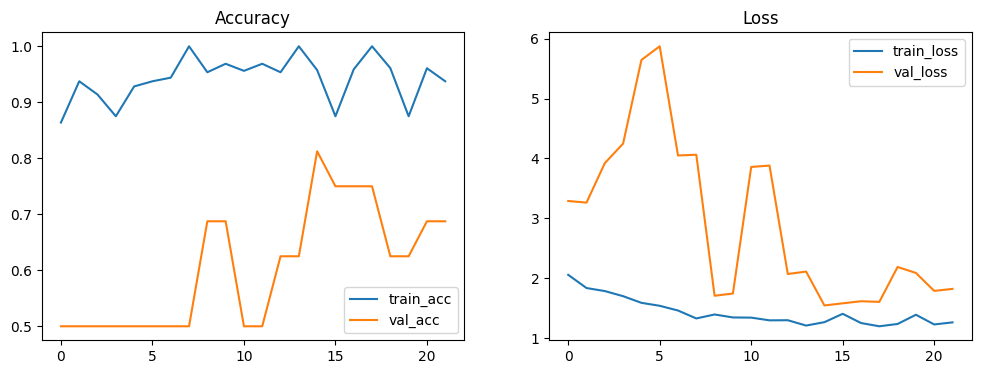

20/20 ━━━━━━━━━━━━━━━━━━━━ 154s 8s/step - accuracy: 0.9067 - loss: 1.4124
CNN test accuracy: 0.8830128312110901 loss: 1.4460394382476807


In [ ]:
# === Cell 4: Compile and train CNN
EPOCHS = 40
optimizer = optimizers.RMSprop(learning_rate=1e-4)   # paper used RMSprop
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks: ReduceLROnPlateau & EarlyStopping & ModelCheckpoint
checkpoint_path = '/content/drive/MyDrive/Machine_Learning/Research_base_Model/cnn_best_weights.h5'
cb_checkpoint = callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
cb_reduce = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, verbose=1, min_lr=1e-7)
cb_early = callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

history = model.fit(
    train_gen,
    steps_per_epoch = max(1, train_gen.n // BATCH_SIZE),
    epochs = EPOCHS,
    validation_data = val_gen,
    validation_steps = max(1, val_gen.n // BATCH_SIZE),
    callbacks=[cb_checkpoint, cb_reduce, cb_early],
    verbose=1
)

# load best weights
if os.path.exists(checkpoint_path):
    model.load_weights(checkpoint_path)
    print("Loaded best weights from checkpoint.")

# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.show()

# Evaluate CNN alone on test set
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print("CNN test accuracy:", test_acc, "loss:", test_loss)


In [ ]:
# === Cell 5: Extract features from the trained CNN ===
# We'll create a model that outputs the 'feature_dense' layer values (64-dim)
feature_model = models.Model(inputs=model.input, outputs=model.get_layer('feature_dense').output)
print("Feature model ready. Output shape example:")
# Generate features for train/val/test using predict (ensure generator not shuffled for val/test)
def extract_all_features(generator, model_feat):
    # predict on generator fully. Use steps = ceil(n / batch_size)
    steps = int(np.ceil(generator.n / generator.batch_size))
    # Reset generator index to ensure same ordering
    generator.reset()
    feats = model_feat.predict(generator, steps=steps, verbose=1)
    labels = generator.classes
    return feats, labels

train_features, train_labels = extract_all_features(train_gen, feature_model)
val_features, val_labels     = extract_all_features(val_gen, feature_model)
test_features, test_labels   = extract_all_features(test_gen, feature_model)

print("train_features shape:", train_features.shape)
print("test_features shape:", test_features.shape)


Feature model ready. Output shape example:
163/163 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step
train_features shape: (5207, 64)
test_features shape: (624, 64)


In [ ]:
# === Cell 6: Train ML classifiers (RF, SVM, KNN) on the extracted features ===
# Standardize features before SVM/KNN
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
val_features_scaled   = scaler.transform(val_features)
test_features_scaled  = scaler.transform(test_features)

# Save scaler
joblib.dump(scaler, '/content/drive/MyDrive/Machine_Learning/Research_base_Model/feature_scaler.pkl')

# 1) Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf.fit(train_features, train_labels)
rf_pred = rf.predict(test_features)
rf_prob = rf.predict_proba(test_features)[:,1] if hasattr(rf, "predict_proba") else None
print("RF accuracy:", accuracy_score(test_labels, rf_pred))

# 2) SVM (use scaled features)
svm = SVC(kernel='rbf', probability=True, random_state=SEED)
svm.fit(train_features_scaled, train_labels)
svm_pred = svm.predict(test_features_scaled)
svm_prob = svm.predict_proba(test_features_scaled)[:,1]
print("SVM accuracy:", accuracy_score(test_labels, svm_pred))

# 3) KNN (scaled)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_features_scaled, train_labels)
knn_pred = knn.predict(test_features_scaled)
knn_prob = knn.predict_proba(test_features_scaled)[:,1]
print("KNN accuracy:", accuracy_score(test_labels, knn_pred))

# Save classifiers
joblib.dump(rf, '/content/drive/MyDrive/Machine_Learning/Research_base_Model/cnn_rf_model.pkl')
joblib.dump(svm, '/content/drive/MyDrive/Machine_Learning/Research_base_Model/cnn_svm_model.pkl')
joblib.dump(knn, '/content/drive/MyDrive/Machine_Learning/Research_base_Model/cnn_knn_model.pkl')

=== Random Forest ===
Accuracy: 0.6217948717948718
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       234
           1     0.6238    0.9949    0.7668       390

    accuracy                         0.6218       624
   macro avg     0.3119    0.4974    0.3834       624
weighted avg     0.3899    0.6218    0.4792       624

Confusion Matrix:
 [[  0 234]
 [  2 388]]

=== SVM ===
Accuracy: 0.625
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       234
           1     0.6250    1.0000    0.7692       390

    accuracy                         0.6250       624
   macro avg     0.3125    0.5000    0.3846       624
weighted avg     0.3906    0.6250    0.4808       624

Confusion Matrix:
 [[  0 234]
 [  0 390]]

=== KNN ===
Accuracy: 0.592948717948718
              precision    recall  f1-score   support

           0     0.3837    0.1410    0.2062       234
           1     0.6264    0.864

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


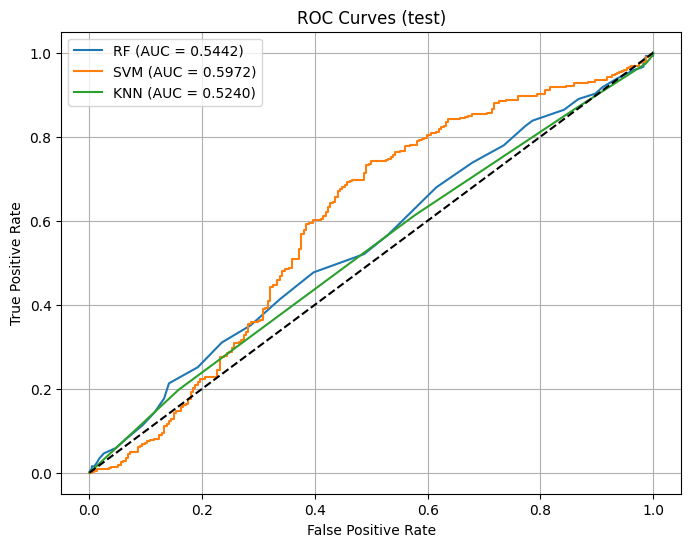

RF AUC: 0.5442472057856673
SVM AUC: 0.5971619548542626
KNN AUC: 0.5240357221126453


In [ ]:
# === Cell 7: Evaluation & metrics ===
def print_evaluation(y_true, y_pred, model_name):
    print("=== {} ===".format(model_name))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)
    print()

print_evaluation(test_labels, rf_pred, "Random Forest")
print_evaluation(test_labels, svm_pred, "SVM")
print_evaluation(test_labels, knn_pred, "KNN")

# ROC / AUC
plt.figure(figsize=(8,6))
def plot_roc(y_true, y_score, label):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.4f})")

if rf_prob is not None:
    plot_roc(test_labels, rf_prob, "RF")
plot_roc(test_labels, svm_prob, "SVM")
plot_roc(test_labels, knn_prob, "KNN")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (test)")
plt.legend()
plt.grid()
plt.show()

# Print AUC values numerically
if rf_prob is not None:
    print("RF AUC:", roc_auc_score(test_labels, rf_prob))
print("SVM AUC:", roc_auc_score(test_labels, svm_prob))
print("KNN AUC:", roc_auc_score(test_labels, knn_prob))

In [ ]:
# === Cell 8: Quick inference function ===
from tensorflow.keras.preprocessing import image
def predict_image(path, cnn_model, feat_model, clf_rf, clf_svm_scaled=None, scaler=None):
    img = image.load_img(path, target_size=IMG_SIZE)
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    feat = feat_model.predict(x)
    rf_pred = clf_rf.predict(feat)[0]
    out = {"RF": int(rf_pred)}
    if clf_svm_scaled is not None and scaler is not None:
        feat_scaled = scaler.transform(feat)
        out["SVM"] = int(clf_svm_scaled.predict(feat_scaled)[0])
    return out

# Example usage (point to an image path in your drive)
# print(predict_image("/content/drive/MyDrive/.../some_test_image.jpeg", model, feature_model, rf, svm, scaler))

print("All done. Models and artifacts saved to your Drive path.")

All done. Models and artifacts saved to your Drive path.


In [ ]:
# === Cell 9: Predict directly from Test Folder ===
# Choose any image from test set and predict Pneumonia / Normal

import cv2
from google.colab.patches import cv2_imshow

def predict_from_test(index=0):
    """
    index = which test image to load (0 to test_gen.n - 1)
    Shows image + prediction from RF, SVM, CNN
    """

    # --- Step 1: Get exact image path from generator ---
    file_path = test_gen.filepaths[index]
    true_label = test_labels[index]

    print("Image path:", file_path)
    print("True label:", "PNEUMONIA" if true_label == 1 else "NORMAL")

    # Load + display image
    img = cv2.imread(file_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print("\n--- Image ---")
    cv2_imshow(img_rgb)

    # --- Step 2: Preprocess for CNN ---
    img_resized = cv2.resize(img_rgb, IMG_SIZE)
    x = img_resized.astype("float32") / 255.0
    x = np.expand_dims(x, axis=0)

    # --- Step 3: CNN prediction ---
    cnn_prob = model.predict(x)[0][0]
    cnn_pred = 1 if cnn_prob >= 0.5 else 0

    # --- Step 4: Feature extraction ---
    feat = feature_model.predict(x)

    # --- Step 5: RF prediction ---
    rf_pred = rf.predict(feat)[0]
    rf_prob = rf.predict_proba(feat)[0][1]

    # --- Step 6: SVM prediction ---
    feat_scaled = scaler.transform(feat)
    svm_pred = svm.predict(feat_scaled)[0]
    svm_prob = svm.predict_proba(feat_scaled)[0][1]

    # --- Final decision (majority vote) ---
    preds = [cnn_pred, rf_pred, svm_pred]
    final = 1 if preds.count(1) >= 2 else 0

    print("\n===== MODEL PREDICTIONS =====")
    print(f"CNN Prediction : {'PNEUMONIA' if cnn_pred else 'NORMAL'} (prob={cnn_prob:.4f})")
    print(f"RF Prediction  : {'PNEUMONIA' if rf_pred else 'NORMAL'} (prob={rf_prob:.4f})")
    print(f"SVM Prediction : {'PNEUMONIA' if svm_pred else 'NORMAL'} (prob={svm_prob:.4f})")
    print("----------------------------------")
    print(f"Final Majority Vote : {'🔥 PNEUMONIA DETECTED' if final else '✅ NORMAL'}")
    print("==================================")

    return {
        "cnn_pred": cnn_pred,
        "rf_pred": rf_pred,
        "svm_pred": svm_pred,
        "final": final,
        "true": true_label
    }

# === Run prediction on test image number (0,1,2,...)
result = predict_from_test(index=0)   # change index to see different images


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# === Cell 10: Save Full CNN Model ===
save_path_cnn = "/content/drive/MyDrive/Machine_Learning/Research_base_Model/final_cnn_model.h5"
model.save(save_path_cnn)
print("CNN model saved at:", save_path_cnn)


CNN model saved at: /content/drive/MyDrive/Machine_Learning/Research_base_Model/final_cnn_model.h5


In [ ]:
# === Cell 11: Save Feature Extractor ===
save_path_feature = "/content/drive/MyDrive/Machine_Learning/Research_base_Model/feature_extractor.h5"
feature_model.save(save_path_feature)
print("Feature extractor saved at:", save_path_feature)


Feature extractor saved at: /content/drive/MyDrive/Machine_Learning/Research_base_Model/feature_extractor.h5


In [ ]:
print(os.listdir("/content/drive/MyDrive/Machine_Learning/Research_base_Model"))
print("⭐⭐⭐ TRAINING NOTEBOOK COMPLETE ✔")

['chest_xray_dataset', 'pneumonia_diagnosis.ipynb', 'cnn_best_weights.h5', 'feature_scaler.pkl', 'cnn_rf_model.pkl', 'cnn_svm_model.pkl', 'cnn_knn_model.pkl', 'pneumonia_diagnosis_1.ipynb', 'final_cnn_model.h5', 'feature_extractor.h5']
⭐⭐⭐ TRAINING NOTEBOOK COMPLETE ✔
